# Assignment 1

## Predicting House Prices in a Messy Market

**Task Challenge**

You have been hired as a junior data scientist by a real estate firm in Ames, Iowa. Your manager wants a model that predicts house sale prices using only the measurable, numeric characteristics of each property, such as square footage, number of rooms, year built, and lot size. She cares less about fancy models and more about whether you understand the data and can justify every decision you make.

## Step 1:

Filter the dataset to keep only columns with numerical data types (int64 and float 64)

In [1]:
import pandas as pd

In [2]:
#checking uploaded file
df = pd.read_csv('train.csv')
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [3]:
#checking dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
#dropping non-numerical columns
non_num_df = df.drop(columns=df.select_dtypes(exclude='number').columns)
print(non_num_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   OverallQual    1460 non-null   int64  
 5   OverallCond    1460 non-null   int64  
 6   YearBuilt      1460 non-null   int64  
 7   YearRemodAdd   1460 non-null   int64  
 8   MasVnrArea     1452 non-null   float64
 9   BsmtFinSF1     1460 non-null   int64  
 10  BsmtFinSF2     1460 non-null   int64  
 11  BsmtUnfSF      1460 non-null   int64  
 12  TotalBsmtSF    1460 non-null   int64  
 13  1stFlrSF       1460 non-null   int64  
 14  2ndFlrSF       1460 non-null   int64  
 15  LowQualFinSF   1460 non-null   int64  
 16  GrLivArea      1460 non-null   int64  
 17  BsmtFullBath   1460 non-null   int64  
 18  BsmtHalf

## Step 2

Exploartory Data Analysis

- Exploring the five numerical features with the strongest correlation with SalePrice and visualizing them with a heatmap.

- Creating scatter plots against SalePrice with the top three features. Checking for patterns and linear relationships.

- Checking for SalePrice distribution. Using histogram to explain what a skewed target variable means for linear regression.

- Identifing at least three outliers in the top features and making a judgment call to keep or drop.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#first calculate the correlation matrix
correlation_matrix = non_num_df.corr()
print(correlation_matrix)

                     Id  MSSubClass  LotFrontage   LotArea  OverallQual  \
Id             1.000000    0.011156    -0.010601 -0.033226    -0.028365   
MSSubClass     0.011156    1.000000    -0.386347 -0.139781     0.032628   
LotFrontage   -0.010601   -0.386347     1.000000  0.426095     0.251646   
LotArea       -0.033226   -0.139781     0.426095  1.000000     0.105806   
OverallQual   -0.028365    0.032628     0.251646  0.105806     1.000000   
OverallCond    0.012609   -0.059316    -0.059213 -0.005636    -0.091932   
YearBuilt     -0.012713    0.027850     0.123349  0.014228     0.572323   
YearRemodAdd  -0.021998    0.040581     0.088866  0.013788     0.550684   
MasVnrArea    -0.050298    0.022936     0.193458  0.104160     0.411876   
BsmtFinSF1    -0.005024   -0.069836     0.233633  0.214103     0.239666   
BsmtFinSF2    -0.005968   -0.065649     0.049900  0.111170    -0.059119   
BsmtUnfSF     -0.007940   -0.140759     0.132644 -0.002618     0.308159   
TotalBsmtSF   -0.015415  

In [7]:
# save file and check for the five features with the highest correlation with sales price
correlation_matrix.to_csv('correlation_matrix.csv')

In [8]:
#select them as a subset from the non_num_df
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', 'SalePrice']
subset = non_num_df[features]
print(subset.head())

   OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  SalePrice
0            7       1710           2         548          856     208500
1            6       1262           2         460         1262     181500
2            7       1786           2         608          920     223500
3            7       1717           3         642          756     140000
4            8       2198           3         836         1145     250000


In [9]:
#calculate the correaltion matrix of the subset
corr_matrix = subset.corr()
print(corr_matrix)

             OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  \
OverallQual     1.000000   0.593007    0.600671    0.562022     0.537808   
GrLivArea       0.593007   1.000000    0.467247    0.468997     0.454868   
GarageCars      0.600671   0.467247    1.000000    0.882475     0.434585   
GarageArea      0.562022   0.468997    0.882475    1.000000     0.486665   
TotalBsmtSF     0.537808   0.454868    0.434585    0.486665     1.000000   
SalePrice       0.790982   0.708624    0.640409    0.623431     0.613581   

             SalePrice  
OverallQual   0.790982  
GrLivArea     0.708624  
GarageCars    0.640409  
GarageArea    0.623431  
TotalBsmtSF   0.613581  
SalePrice     1.000000  


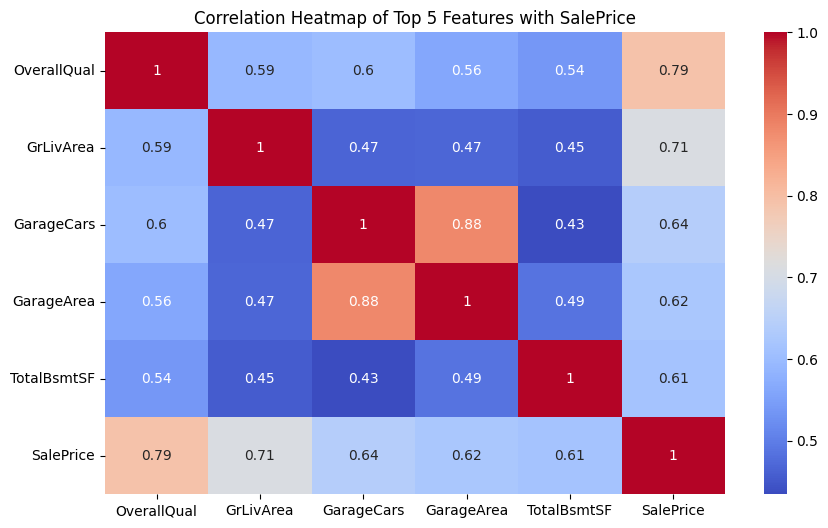

In [10]:
#plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap of Top 5 Features with SalePrice')
plt.savefig('corr_heatmap.png')
plt.show()

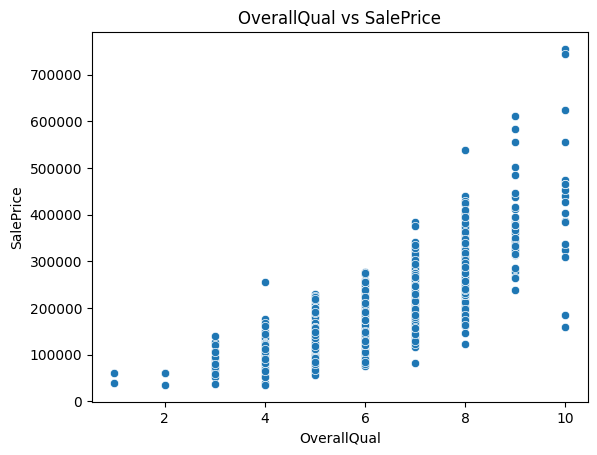

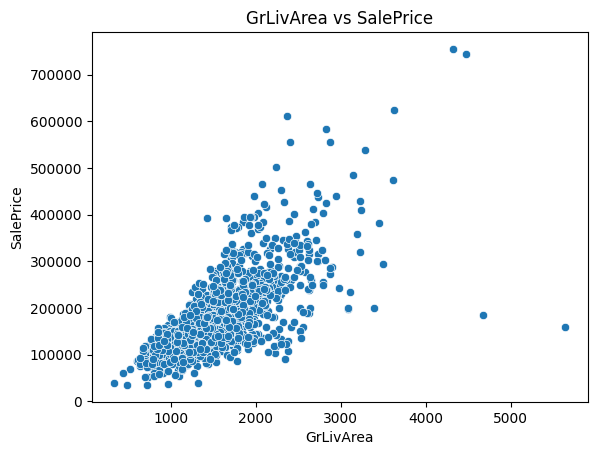

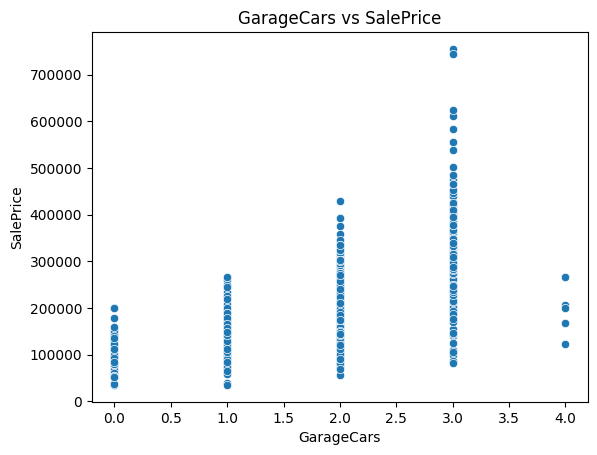

In [11]:
#scatter plot of top three
features = ['OverallQual', 'GrLivArea', 'GarageCars']

for col in features:
    sns.scatterplot(data=non_num_df, x=col, y='SalePrice')
    plt.title(f'{col} vs SalePrice')
    plt.savefig('scatter_plot_assignment.png')
    plt.show()

The scatter plot above shows a more positive relationship between OverallQual, GrLivArea and GarageCars with OverallQual having the strongest relationship, GrLivArea a moderate relationship and GarageCars a weaker relationship.

All the features in the graph have linear relationships with SalePrice. As you move higher, the prices tend to increase. However, the ground living area and garage size alone does not determine the price.


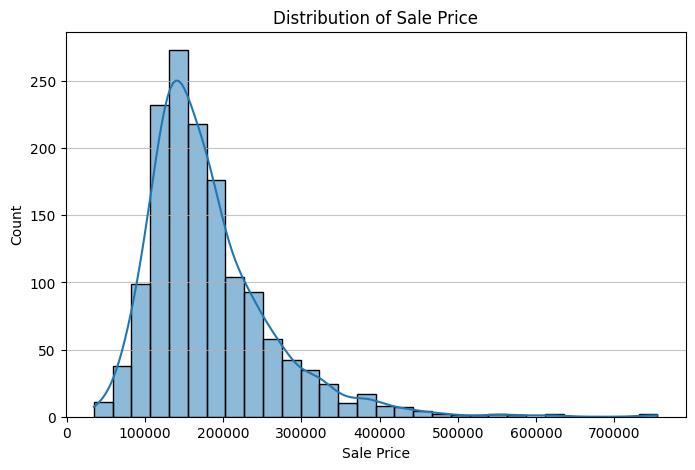

In [12]:
#plot a histogram to show distribution of sale price

plt.figure(figsize=(8, 5))
sns.histplot(data=non_num_df, x="SalePrice", kde=True, bins=30)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.75)
plt.savefig('histogram_assignment.png')
plt.show()

The histogram plot shows an abnormal distribution of sales price. Most values are concentrated on the lower-to-middle price range. There is a long tail extending to the right, indicating a few very high sales prices.

In linear regression, one key assumption is that the residuals (errors) are normally distributed - not necessarily the target itself. However, a strongly skewed target often leads to skewed residuals, which can affect model performance. This implies that there will be bias in prediction, violation of assumptions, heteroscedasticity (variance of errors may increase with the target value) and reduced model accuracy.


As seen in the scatter plot also, there are a few outliers in the OverallQual feature, but they are not very extreme. Some points do not follow the pattern. An example is seen in a house with moderate quality (4-5) but an unusually high price and a house with high quality (9-10) but a much lower price than others at that level. Some outliers too can be spotted in level 10 with the value being extremely high and far away from the cluster. In the GrLivArea feature, we can spot some very large houses with unusual prices as seen between 4000 - 7000 sqft and smaller houses with extremely high prices as seen between 4000 - 5000 sqft. The outliers in the GarageCars feature are more noticeable. Examples are a house with 4 garage spaces but a relatively low price (far below others at 4) and some houses with 3 garage spaces and extremely high prices compared to others.

The outliers seen in the OverallQual are realistic in real life. Location, condition or timing can affect house price and so they do not break the overall trend. Removing them may reduce real-world variability. The extreme outliers in GrLivArea will be dropped (especially large size + low price) and the consistent high-price + large houses will be kept. Large houses + very low price is suspicious (could be data error or unusual case) and they can pull the regression line wrongly. Garage size is not a strong predictor alone, variation is expected and realistic. Removing them may remove valid diversity in data and so most of them will be kept.


##Step 3
Data Cleaning

In [13]:
non_num_df.isnull().sum()

,0
Id,0
MSSubClass,0
LotFrontage,259
LotArea,0
OverallQual,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
MasVnrArea,8
BsmtFinSF1,0


Quite a number of cells in the LotFrontage column are missing,
dropping them might reduce model quality.
Missing Lot fronatge is often not random,
could depend on neighbourhood or lot type.

In housing data, Lot frontage are often skewed,
so it makes sense to fill missing values with the median.


In [14]:
#fill missing values in LotFrontage with median
non_num_df['LotFrontage'].fillna(non_num_df['LotFrontage'].median(), inplace=True)


/tmp/ipykernel_4026/3352644978.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  non_num_df['LotFrontage'].fillna(non_num_df['LotFrontage'].median(), inplace=True)


A few cells have missing values in the MasVnrArea column.
Similar rows also have missing MasVnrType data.
This clearly suggest that the missing cells mean no masonry veneer


In [15]:
#fill missing values in MasVnrArea with 0
non_num_df['MasVnrArea'].fillna(0, inplace=True)

/tmp/ipykernel_4026/2916058679.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  non_num_df['MasVnrArea'].fillna(0, inplace=True)


There are 0 GarageCars and 0 GarageArea
in the rows that have missing GarageYrBlt values.
This implies that no garage exist.

In [16]:
#fill missing values in GarageYrBlt with 0
non_num_df['GarageYrBlt'].fillna(0, inplace=True)

/tmp/ipykernel_4026/2393574425.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  non_num_df['GarageYrBlt'].fillna(0, inplace=True)


In [17]:
non_num_df.isnull().sum()

,0
Id,0
MSSubClass,0
LotFrontage,0
LotArea,0
OverallQual,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
MasVnrArea,0
BsmtFinSF1,0


## Step 4
**Feature Engineering**

Creating three new numerical features from existing ones
1. TotalSF equals 1stFlrSF plus 2ndFlrSF plus TotalBsmtSF
2. HouseAge equals YrSold minus YearBuilt
3. TotalBathrooms equals FullBath plus 0.5 times HalfBath
4. YearsSinceRemodel equals YrSold minus YearRemodAdd

And appling log transformation to SalePrice

In [18]:
#add new columns
non_num_df['TotalSF'] = non_num_df['1stFlrSF'] + non_num_df['2ndFlrSF'] + non_num_df['TotalBsmtSF']
non_num_df['HouseAge'] = non_num_df['YrSold'] - non_num_df['YearBuilt']
non_num_df['TotalBathrooms'] = non_num_df['FullBath'] + 0.5 * non_num_df['HalfBath']
non_num_df['YearsSinceRemodel'] = non_num_df['YrSold'] - non_num_df['YearRemodAdd']
print(non_num_df[['TotalSF', 'HouseAge', 'TotalBathrooms', 'YearsSinceRemodel']].head())

   TotalSF  HouseAge  TotalBathrooms  YearsSinceRemodel
0     2566         5             2.5                  5
1     2524        31             2.0                 31
2     2706         7             2.5                  6
3     2473        91             1.0                 36
4     3343         8             2.5                  8


When the target variable is highly skewed, linear regression struggles because its assumptions are violated. A log transformation helps by making the problem better aligned with those assumptions.

Log transformation:

- Makes the target more normally distributed

- Stabilizes variance

- Converts nonlinear patterns into linear ones

- Reduces outlier impact

In [19]:
#applying log transformation to SalePrice
import numpy as np

non_num_df['SalePrice_log'] = np.log(non_num_df['SalePrice'])

## Step 5

**Scaling**

Scaling matters in linear regression because it:

1. Improves optimization performance

2. Ensures fair regularization

3. Makes coefficients more interpretable

4. Prevents numerical issues

It does not change the underlying relationships, but it significantly affects how well the model is trained and behaves in practice.

Before scaling, It is important to split the data so that the scaler is fitted only on the training data, preventing information from the validation set from influencing the model.

In [20]:
# defining features
features = non_num_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
features.remove('SalePrice')        # if present
features.remove('SalePrice_log')    # important

In [21]:
#splitting the non_num_df into train and val set
from sklearn.model_selection import train_test_split

X = non_num_df[features]
y = non_num_df['SalePrice_log']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
#fit scaler on x_train only
from sklearn.preprocessing import StandardScaler

st = StandardScaler()
X_train_scaled = st.fit_transform(X_train)
X_val_scaled = st.transform(X_val)

## Step 6
**Modeling**


In [23]:
#train model on x_train
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

## Step 7
**Cross Validation**

In [25]:
#using a pipeline to avoid leakage during cross validation
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [26]:
#performing cross validation on the training data using RMSE
from sklearn.model_selection import cross_validate
import numpy as np

cv_results = cross_validate(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    return_train_score=True
)

train_rmse_cv = -cv_results['train_score']
val_rmse_cv = -cv_results['test_score']

print(train_rmse_cv.mean())
print(val_rmse_cv.mean())

0.1417669547801424
0.15951206155940598


## Step 8
**Trying out Ridge Regression**

Ridge regression reduces overfitting in linear models by adding an L2 penalty that shrinks coefficients toward zero without eliminating them. In order words, I am trying to see if i can get a lower rmse score.

In [27]:
#import ridge and metrics
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

In [28]:
#train ridge model
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

Ridge()

In [29]:
#make predictions
#train predictions
y_train_pred_ridge = ridge_model.predict(X_train_scaled)

#validation/cv-style holdout predictions
y_val_pred_ridge = ridge_model.predict(X_val_scaled)

In [30]:
#compute rmse
#train rmse
train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
print(train_rmse_ridge)

#validation rmse
val_rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
print(val_rmse_ridge)

0.14400081741080373
0.15186327488624496


In [31]:
#try multiple alpha values
for a in [0.1, 1, 10, 50, 100]:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    preds = ridge.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    print(f"alpha={a}, RMSE={rmse}")

alpha=0.1, RMSE=0.1518762100209578
alpha=1, RMSE=0.15186327488624496
alpha=10, RMSE=0.1517550354585736
alpha=50, RMSE=0.1516097060074732
alpha=100, RMSE=0.15187250047997258


The best alpha is the alpha with the lowest rmse is 50 (rmse = 0.1516). Comparing it with my previous model, i have a meaningful realtive gain (~ 5% reduction in error) which moves me further below the 0.16 threshold.

## Step 9
Predicting Sale Price on a held out dataset

In [32]:
import pandas as pd

test_df = pd.read_csv("test.csv")

In [50]:
#dropping non-numerical columns
test_df = df.drop(columns=df.select_dtypes(exclude='number').columns)
print(non_num_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 1460 non-null   int64  
 1   MSSubClass         1460 non-null   int64  
 2   LotFrontage        1460 non-null   float64
 3   LotArea            1460 non-null   int64  
 4   OverallQual        1460 non-null   int64  
 5   OverallCond        1460 non-null   int64  
 6   YearBuilt          1460 non-null   int64  
 7   YearRemodAdd       1460 non-null   int64  
 8   MasVnrArea         1460 non-null   float64
 9   BsmtFinSF1         1460 non-null   int64  
 10  BsmtFinSF2         1460 non-null   int64  
 11  BsmtUnfSF          1460 non-null   int64  
 12  TotalBsmtSF        1460 non-null   int64  
 13  1stFlrSF           1460 non-null   int64  
 14  2ndFlrSF           1460 non-null   int64  
 15  LowQualFinSF       1460 non-null   int64  
 16  GrLivArea          1460 

In [51]:
#handling missing values
test_df['LotFrontage'].fillna(test_df['LotFrontage'].median(), inplace=True)
test_df['MasVnrArea'].fillna(0, inplace=True)
test_df['GarageYrBlt'].fillna(0, inplace=True)

/tmp/ipykernel_4026/1274812622.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['LotFrontage'].fillna(test_df['LotFrontage'].median(), inplace=True)
/tmp/ipykernel_4026/1274812622.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

In [52]:
test_df.isnull().sum()

,0
Id,0
MSSubClass,0
LotFrontage,0
LotArea,0
OverallQual,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
MasVnrArea,0
BsmtFinSF1,0


In [53]:
#replicating feature engineering done on non_num_df to test_df
test_df['TotalSF'] = test_df['1stFlrSF'] + test_df['2ndFlrSF'] + test_df['TotalBsmtSF']
test_df['HouseAge'] = test_df['YrSold'] - test_df['YearBuilt']
test_df['TotalBathrooms'] = test_df['FullBath'] + 0.5 * test_df['HalfBath']
test_df['YearsSinceRemodel'] = test_df['YrSold'] - test_df['YearRemodAdd']

In [54]:
#selecting the same features used in training
X_test = test_df[features]

In [55]:
#applying the same scaling
X_test_scaled = st.transform(X_test)

In [56]:
#import ridge
from sklearn.linear_model import Ridge

In [57]:
#train final model on full training data
final_model = Ridge(alpha=50)
final_model.fit(X_train_scaled, y_train)

Ridge(alpha=50)

In [58]:
#predict on test set
y_test_pred = final_model.predict(X_test_scaled)

In [59]:
#convert log(SalePrice) back to original scale
import numpy as np

y_test_pred_original = np.exp(y_test_pred)

In [60]:
#create submission file
import pandas as pd

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": y_test_pred_original
})

submission.to_csv("submission.csv", index=False)

##Reflection

In [61]:
#checking for biggest prediction errors
import pandas as pd

errors = abs(y_val - y_val_pred_ridge)

In [62]:
#get largest errors
largest_errors = errors.sort_values(ascending=False).head(10)

In [68]:
#inspecting the rows
problem_rows = X_val.loc[largest_errors.index]

In [65]:
#create an analysis table
y_val_pred_ridge = pd.Series(y_val_pred_ridge, index=y_val.index)
analysis = pd.DataFrame({
    'Actual': y_val.loc[largest_errors.index],
    'Predicted': y_val_pred_ridge[largest_errors.index],
    'Error': largest_errors
})
print(analysis)

         Actual  Predicted     Error
30    10.596635  11.373634  0.777000
812   10.932982  11.588380  0.655398
916   10.471950  11.116140  0.644190
874   11.104957  11.559302  0.454345
1432  11.074421  11.526867  0.452447
898   13.323927  12.906507  0.417420
277   11.856515  11.462209  0.394307
669   11.831379  11.463420  0.367959
1046  13.229568  12.872050  0.357518
1170  12.049419  11.703002  0.346417
